# 딥러닝-분류 모델링(2 Class)

Titanic 데이터를 사용해 PyTorch 기반 DNN 이진분류 모델을 만들고 비교합니다.

이 노트북의 목표는 다음과 같습니다.

- pandas/numpy 데이터를 PyTorch `DataLoader`와 텐서로 변환한다.
- 이진분류 모델의 출력층에 `Sigmoid`를 사용하고, 손실 함수로 `BCELoss`를 사용한다.
- 입력 변수 수와 은닉층 구조를 바꾸며 분류 성능을 비교한다.
- confusion matrix와 classification report로 모델을 평가한다.

## 1. 환경 준비

필요한 라이브러리를 불러오고, 반복해서 사용할 함수들을 먼저 정의합니다.

### 1.1 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

### 1.2 필요 함수 생성

아래 3개 함수가 학습 흐름의 핵심입니다.

- `make_DataSet`: 학습 데이터는 `DataLoader`로 만들고, 검증 데이터는 텐서로 변환합니다.
- `train`: 한 epoch 동안 미니배치 학습을 수행합니다.
- `evaluate`: 검증 데이터 전체에 대해 손실과 예측값을 반환합니다.

- `make_DataSet` 함수 : 딥러닝을 위한 데이터로더 만들기

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(np.array(x_train), dtype=torch.float32)
    y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(np.array(x_val), dtype=torch.float32)
    y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor

- `train` 함수 : 학습을 위한 함수

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Feed Forward
        optimizer.zero_grad()              # 이전 배치의 gradient를 초기화
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()                    # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()                   # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)  # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적

    return total_loss / len(dataloader.dataset)  # 전체 데이터 개수로 나누어 epoch 평균 loss 반환

- `evaluate` 함수 : 검증을 위한 함수

In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()  # 모델을 평가 모드로 설정

    with torch.no_grad():  # 평가 과정에서는 기울기를 계산하지 않음
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()

    return eval_loss, pred

- 학습 곡선

In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### 1.3 Device 준비

GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## 2. 데이터 준비

Titanic 데이터는 승객 정보를 바탕으로 생존 여부(`Survived`)를 예측하는 이진분류 데이터입니다.

| 변수 | 설명 |
| ---- | ---- |
| Survived | 생존 여부(0: 사망, 1: 생존) |
| Pclass | 객실 등급 |
| Sex | 성별 |
| Age | 나이 |
| Fare | 요금 |
| Embarked | 승선 항구 |
| Family | 동반 가족 수 |

In [8]:
path = 'titanic.csv'
df = pd.read_csv(path)
df.drop(['Age_scale1', 'AgeGroup', 'SibSp', 'Parch'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Family
0,0,3,male,22.0,7.2500,S,2
1,1,1,female,38.0,71.2833,C,2
2,1,3,female,26.0,7.9250,S,1
3,1,1,female,35.0,53.1000,S,2
4,0,3,male,35.0,8.0500,S,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   Fare      891 non-null    float64
 5   Embarked  891 non-null    object 
 6   Family    891 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [10]:
df.describe(include='all')

,Survived,Pclass,Sex,Age,Fare,Embarked,Family
count,891.000000,891.000000,891,891.000000,891.000000,891,891.000000
unique,NaN,NaN,2,NaN,NaN,3,NaN
top,NaN,NaN,male,NaN,NaN,S,NaN
freq,NaN,NaN,577,NaN,NaN,646,NaN
mean,0.383838,2.308642,NaN,29.754770,32.204208,NaN,1.904602
std,0.486592,0.836071,NaN,13.277378,49.693429,NaN,1.613459
min,0.000000,1.000000,NaN,0.420000,0.000000,NaN,1.000000
25%,0.000000,2.000000,NaN,21.770000,7.910400,NaN,1.000000
50%,0.000000,3.000000,NaN,30.000000,14.454200,NaN,1.000000
75%,1.000000,3.000000,NaN,35.900000,31.000000,NaN,2.000000


## 3. 모델링 1: 주요 변수 3개로 이진분류 모델 만들기

먼저 `Sex`, `Age`, `Fare` 3개 변수만 사용합니다. 모델은 입력층과 출력층만 있는 가장 단순한 이진분류 구조입니다.

### 3.1 데이터 전처리

- X, y 나누기
    - X : `Sex`, `Age`, `Fare`
    - y : `Survived`

In [11]:
target = 'Survived'
features = ['Sex', 'Age', 'Fare']

X = df.loc[:, features]
y = df[target]

- 가변수화

In [12]:
X = pd.get_dummies(X, columns=['Sex'], drop_first=True)
X.head()

,Age,Fare,Sex_male
0,22.0,7.2500,True
1,38.0,71.2833,False
2,26.0,7.9250,False
3,35.0,53.1000,False
4,35.0,8.0500,True


- 데이터 분할

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                  test_size=.2,
                                                  random_state=2026)

- 스케일링

In [14]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

### 3.2 딥러닝을 위한 준비작업
- make_DataLoader

In [15]:
train_loader, X_val_ts, y_val_ts = make_DataSet(X_train,
                                                X_val,
                                                y_train,
                                                y_val,
                                                batch_size=32)

In [16]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(x.shape)
    print(y.shape, y.dtype)
    break

torch.Size([32, 3])
torch.Size([32, 1]) torch.float32


### 3.3 모델 선언
- nn.Linear(입력, 출력) 레이어 한 개 추가
- 이진분류이므로 출력층 뒤에 `Sigmoid` 활성화 함수를 사용

In [17]:
X.shape[1]

3

In [18]:
n_feature = X.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 1),
    nn.Sigmoid()                # 시그모이드 활성화 함수 사용(회귀 모델과 다른점)
).to(device)

print(model1)

Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
  (1): Sigmoid()
)


- Loss function과 Optimizer
    - loss function : Binary Cross Entropy
    - Optimizer : Adam(모델 파라미터, 학습률)

In [19]:
loss_fn = nn.BCELoss()          # Binary Cross Entropy(회귀 모델과 다른점)
optimizer = Adam(model1.parameters(), lr=0.01)

### 3.4 모델 학습

In [20]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.707035, val loss : 0.670062
Epoch 2, train loss : 0.653938, val loss : 0.638074
Epoch 3, train loss : 0.628098, val loss : 0.619456
Epoch 4, train loss : 0.612472, val loss : 0.603387
Epoch 5, train loss : 0.599053, val loss : 0.588373
Epoch 6, train loss : 0.585420, val loss : 0.575661
Epoch 7, train loss : 0.574009, val loss : 0.564220
Epoch 8, train loss : 0.564098, val loss : 0.554232
Epoch 9, train loss : 0.555070, val loss : 0.545076
Epoch 10, train loss : 0.546971, val loss : 0.537531
Epoch 11, train loss : 0.540138, val loss : 0.530297
Epoch 12, train loss : 0.534172, val loss : 0.524122
Epoch 13, train loss : 0.529553, val loss : 0.520335
Epoch 14, train loss : 0.524868, val loss : 0.516184
Epoch 15, train loss : 0.521672, val loss : 0.512584
Epoch 16, train loss : 0.518041, val loss : 0.508865
Epoch 17, train loss : 0.515345, val loss : 0.506488
Epoch 18, train loss : 0.513610, val loss : 0.504617
Epoch 19, train loss : 0.510730, val loss : 0.502380
Ep

- 학습된 파라미터 확인

In [21]:
for name, param in model1.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-0.6924,  6.2414, -2.3509]], device='cuda:0')
Parameter: 0.bias, Value: tensor([0.8655], device='cuda:0')


- 학습 곡선

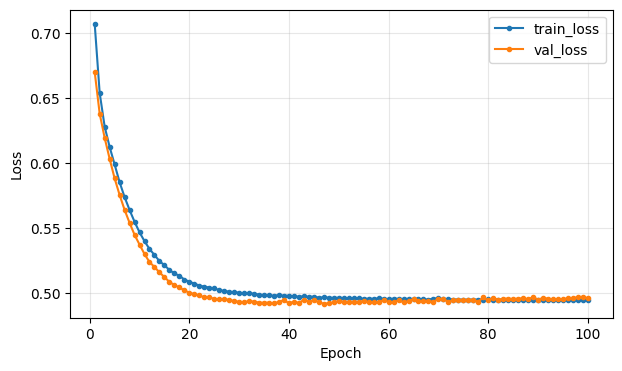

In [22]:
dl_learning_curve(tr_loss_list, val_loss_list)

### 3.5 모델 평가

In [23]:
_, pred = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)

- **[회귀와 다른 점]** 예측 결과는 0 ~ 1 사이의 확률값
    - 확률값을 0, 1의 클래스로 변환 필요.
    - 여기서는 0.5를 기준으로 이진 분류.
    - np.where(조건문, True일때 값, False일때 값)

In [24]:
pred.cpu().numpy()[:5]      # Numpy는 기본적으로 CPU 메모리의 데이터만 다룰 수 있음

array([[0.6827766 ],
       [0.17895548],
       [0.75035733],
       [0.16713093],
       [0.7187901 ]], dtype=float32)

In [25]:
# 모델의 예측 값 변환(0.5를 기준으로 이진 분류)
pred_class = np.where(pred.cpu().numpy() > 0.5, 1, 0)   # 확률이 0.5보다 크면 1, 작으면 0으로 변환
pred_class[:5]

array([[1],
       [0],
       [1],
       [0],
       [1]])

- confusion matrix

In [26]:
confusion_matrix(y_val_ts.cpu().numpy(), pred_class)

array([[85, 23],
       [16, 55]])

- classification_report

In [27]:
print(classification_report(y_val_ts.cpu().numpy(), pred_class))

              precision    recall  f1-score   support

         0.0       0.84      0.79      0.81       108
         1.0       0.71      0.77      0.74        71

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179



---

## 4. 모델링 2: 전체 변수로 이진분류 모델 만들기

- 이제 `Survived`를 제외한 모든 변수를 사용합니다.
- 모델 구조는 여전히 입력층과 출력층만 있는 단순한 이진분류 모델입니다.

### 4.1 데이터 전처리

- 데이터 준비

In [28]:
target = 'Survived'
X = df.drop(target, axis=1)
y = df.loc[:, target]

- 가변수화

In [29]:
cat_cols = ['Pclass', 'Sex', 'Embarked']
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X.head()

,Age,Fare,Family,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,22.0,7.2500,2,False,True,True,False,True
1,38.0,71.2833,2,False,False,False,False,False
2,26.0,7.9250,1,False,True,False,False,True
3,35.0,53.1000,2,False,False,False,False,True
4,35.0,8.0500,1,False,True,True,False,True


- 데이터 분할

In [30]:
X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y,
                                                  test_size=0.2,
                                                  random_state=2026)

- 스케일링

In [31]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

### 4.2 모델링

- make_DataLoader

In [32]:
train_loader, X_val_ts, y_val_ts = make_DataSet(X_train, X_val, y_train, y_val, batch_size=32)

- 모델 설계

In [33]:
X.shape

(891, 8)

In [34]:
n_feature = X.shape[1]

# 모델 구조 설계
model2 = nn.Sequential(
    nn.Linear(n_feature, 1),
    nn.Sigmoid()
).to(device)

print(model2)

Sequential(
  (0): Linear(in_features=8, out_features=1, bias=True)
  (1): Sigmoid()
)


- Loss function과 Optimizer

In [35]:
loss_fn = nn.BCELoss()
optimizer = Adam(model2.parameters(), lr=0.01)

### 4.3 모델 학습

In [36]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model2, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.643898, val loss : 0.597682
Epoch 2, train loss : 0.584577, val loss : 0.575023
Epoch 3, train loss : 0.568651, val loss : 0.559699
Epoch 4, train loss : 0.554153, val loss : 0.546189
Epoch 5, train loss : 0.542267, val loss : 0.534364
Epoch 6, train loss : 0.531904, val loss : 0.524563
Epoch 7, train loss : 0.522326, val loss : 0.516169
Epoch 8, train loss : 0.515257, val loss : 0.509032
Epoch 9, train loss : 0.508462, val loss : 0.502755
Epoch 10, train loss : 0.503031, val loss : 0.497485
Epoch 11, train loss : 0.498174, val loss : 0.492354
Epoch 12, train loss : 0.494046, val loss : 0.488117
Epoch 13, train loss : 0.490586, val loss : 0.485153
Epoch 14, train loss : 0.487119, val loss : 0.482103
Epoch 15, train loss : 0.484293, val loss : 0.480118
Epoch 16, train loss : 0.481580, val loss : 0.477661
Epoch 17, train loss : 0.479156, val loss : 0.475550
Epoch 18, train loss : 0.477199, val loss : 0.473206
Epoch 19, train loss : 0.476839, val loss : 0.472096
Ep

- 학습된 파라미터 확인

In [37]:
for name, param in model2.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-1.7960,  2.9740, -1.5360, -0.5725, -1.6505, -2.4865, -0.0090, -0.3407]],
       device='cuda:0')
Parameter: 0.bias, Value: tensor([2.9457], device='cuda:0')


- 학습 곡선

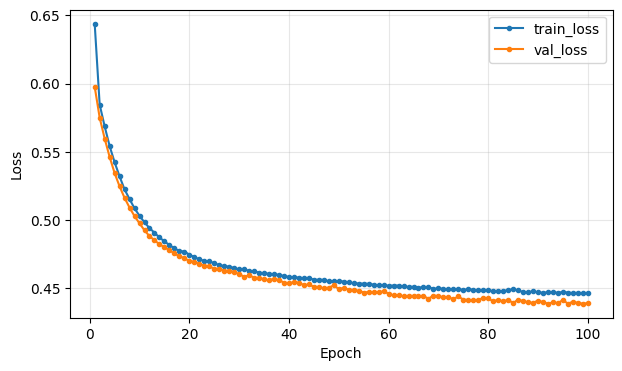

In [38]:
dl_learning_curve(tr_loss_list, val_loss_list)

### 4.4 모델 평가

In [39]:
_, pred = evaluate(X_val_ts, y_val_ts, model2, loss_fn, device)

In [40]:
pred_class = np.where(pred.cpu().numpy() > 0.5, 1, 0)
pred_class[:5]

array([[1],
       [0],
       [1],
       [0],
       [1]])

- confusion matrix

In [41]:
confusion_matrix(y_val_ts.numpy(), pred_class)

array([[92, 16],
       [17, 54]])

- classification_report

In [42]:
print(classification_report(y_val_ts.numpy(), pred_class))

              precision    recall  f1-score   support

         0.0       0.84      0.85      0.85       108
         1.0       0.77      0.76      0.77        71

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



---

## 5. 모델링 3: 은닉층 추가
- 데이터 전처리와 DataLoader는 `4. 모델링 2`에서 준비한 것을 그대로 사용합니다.

### 5.1 데이터 전처리
- `4. 모델링 2`에서 준비한 데이터 그대로 이용

### 5.2 모델링
- `4. 모델링 2`에서 선언한 DataLoader를 그대로 사용

- 모델 설계

In [43]:
n_feature = X.shape[1]

# 모델 구조 설계
model3 = nn.Sequential(
    nn.Linear(n_feature, 5),        # 은닉층
    nn.ReLU(),                      # 은닉층 활성화 함수
    nn.Linear(5,1),                 # 출력층
    nn.Sigmoid()                    # 출력층 활성화 함수
).to(device)

print(model3)

Sequential(
  (0): Linear(in_features=8, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
  (3): Sigmoid()
)


- Loss function과 Optimizer

In [44]:
loss_fn = nn.BCELoss()
optimizer = Adam(model3.parameters(), lr=0.001)     # 0.01 ~ 0.00001

### 5.3 모델 학습

In [45]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model3, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.691220, val loss : 0.685536
Epoch 2, train loss : 0.682099, val loss : 0.676647
Epoch 3, train loss : 0.672887, val loss : 0.667081
Epoch 4, train loss : 0.662680, val loss : 0.659083
Epoch 5, train loss : 0.653774, val loss : 0.650112
Epoch 6, train loss : 0.644690, val loss : 0.642604
Epoch 7, train loss : 0.636769, val loss : 0.634983
Epoch 8, train loss : 0.628969, val loss : 0.627234
Epoch 9, train loss : 0.621245, val loss : 0.620586
Epoch 10, train loss : 0.614448, val loss : 0.613426
Epoch 11, train loss : 0.607564, val loss : 0.606784
Epoch 12, train loss : 0.601146, val loss : 0.600092
Epoch 13, train loss : 0.594257, val loss : 0.593215
Epoch 14, train loss : 0.587482, val loss : 0.586098
Epoch 15, train loss : 0.580753, val loss : 0.579540
Epoch 16, train loss : 0.574541, val loss : 0.573130
Epoch 17, train loss : 0.568542, val loss : 0.566794
Epoch 18, train loss : 0.562526, val loss : 0.560840
Epoch 19, train loss : 0.556828, val loss : 0.554723
Ep

- 학습된 파라미터 확인

In [46]:
for name, param in model3.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[ 0.5981, -0.8497,  0.3178,  0.2563,  0.7180,  0.5593,  0.0127,  0.3021],
        [ 0.1957, -0.0312, -0.2696, -0.2683, -0.2130, -0.2870, -0.0871, -0.0645],
        [ 0.0020, -0.0712,  0.0195, -0.1136, -0.2715, -0.1676, -0.1626, -0.2762],
        [ 0.5642,  1.0761, -0.1733,  0.1310, -0.4009, -1.4290,  0.5459,  0.2201],
        [ 0.3912, -0.7254,  0.2882,  0.0645,  0.8262,  0.8079,  0.3369,  0.4244]],
       device='cuda:0')
Parameter: 0.bias, Value: tensor([-0.2308, -0.2128, -0.3315,  0.7502, -0.1587], device='cuda:0')
Parameter: 2.weight, Value: tensor([[-0.7511, -0.0118,  0.2669,  1.4679, -0.6429]], device='cuda:0')
Parameter: 2.bias, Value: tensor([0.3991], device='cuda:0')


- 학습 곡선

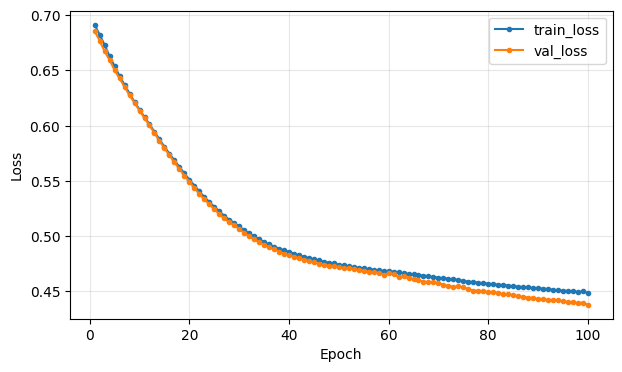

In [47]:
dl_learning_curve(tr_loss_list, val_loss_list)

### 5.4 모델 평가

In [48]:
_, pred = evaluate(X_val_ts, y_val_ts, model3, loss_fn, device)

In [49]:
pred_class = np.where(pred.cpu().numpy() > 0.5, 1, 0)
pred_class[:10]

array([[1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0]])

- confusion matrix

In [50]:
confusion_matrix(y_val_ts.cpu().numpy(), pred_class)

array([[97, 11],
       [22, 49]])

- classification_report

In [51]:
print(classification_report(y_val_ts.cpu().numpy(), pred_class))

              precision    recall  f1-score   support

         0.0       0.82      0.90      0.85       108
         1.0       0.82      0.69      0.75        71

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



---

## **6. 연습문제1**

- 다음의 모델 구조대로 모델링을 수행하고 성능평가를 해 봅시다.
    - 모델 구조

            Sequential(
                (0): Linear(in_features=8, out_features=10, bias=True)
                (1): ReLU()
                (2): Linear(in_features=10, out_features=5, bias=True)
                (3): ReLU()
                (4): Linear(in_features=5, out_features=1, bias=True)
                (5): Sigmoid()
            )
    - epochs(반복횟수) : 100
    - lr(learning rate, 학습률) : 0.001

- 이진분류 문제이므로 마지막 출력층에는 `Sigmoid`를 사용합니다.
- 학습 곡선과 classification report를 함께 확인합니다.

- 모델 설계

In [52]:
n_feature = X.shape[1]

model4 = nn.Sequential(
    nn.Linear(n_feature, 10),
    nn.ReLU(),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5, 1),
    nn.Sigmoid()
).to(device)

print(model4)

Sequential(
  (0): Linear(in_features=8, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=1, bias=True)
  (5): Sigmoid()
)


- Loss function과 Optimizer

In [53]:
loss_fn = nn.BCELoss()
optimizer = Adam(model4.parameters(), lr=0.001)

- 모델 학습

In [54]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model4, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model4, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.739123, val loss : 0.727291
Epoch 2, train loss : 0.725398, val loss : 0.713442
Epoch 3, train loss : 0.708206, val loss : 0.693718
Epoch 4, train loss : 0.679014, val loss : 0.660367
Epoch 5, train loss : 0.644191, val loss : 0.629766
Epoch 6, train loss : 0.614702, val loss : 0.603967
Epoch 7, train loss : 0.590437, val loss : 0.583948
Epoch 8, train loss : 0.570608, val loss : 0.565045
Epoch 9, train loss : 0.552577, val loss : 0.547799
Epoch 10, train loss : 0.535903, val loss : 0.532487
Epoch 11, train loss : 0.521375, val loss : 0.517909
Epoch 12, train loss : 0.508908, val loss : 0.506667
Epoch 13, train loss : 0.499070, val loss : 0.497406
Epoch 14, train loss : 0.490751, val loss : 0.490876
Epoch 15, train loss : 0.484770, val loss : 0.484685
Epoch 16, train loss : 0.479124, val loss : 0.478250
Epoch 17, train loss : 0.474632, val loss : 0.473682
Epoch 18, train loss : 0.470902, val loss : 0.469591
Epoch 19, train loss : 0.467504, val loss : 0.466486
Ep

- 학습 곡선

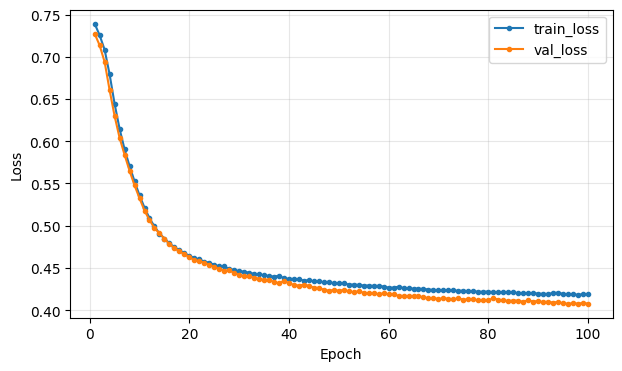

In [55]:
dl_learning_curve(tr_loss_list, val_loss_list)

- 모델 평가

In [56]:
_, pred = evaluate(X_val_ts, y_val_ts, model4, loss_fn, device)

In [57]:
pred_class = np.where(pred.cpu().numpy() > 0.5, 1, 0)
pred_class[:5]

array([[1],
       [0],
       [1],
       [0],
       [1]])

- confusion matrix

In [58]:
confusion_matrix(y_val_ts.cpu().numpy(), pred_class)

array([[98, 10],
       [24, 47]])

- classification_report

In [59]:
print(classification_report(y_val_ts.cpu().numpy(), pred_class))

              precision    recall  f1-score   support

         0.0       0.80      0.91      0.85       108
         1.0       0.82      0.66      0.73        71

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



## **7. 연습문제2**
- 여러분이 원하는 구조와 하이퍼파라미터 값을 조정하여 성능을 높여 봅시다.


In [61]:
n_feature = X.shape[1]

model5 = nn.Sequential(
    nn.Linear(n_feature, 100),
    nn.ReLU(),
    nn.Linear(100, 50),
    nn.ReLU(),
    nn.Linear(50, 25),
    nn.ReLU(),
    nn.Linear(25, 1),
    nn.Sigmoid()
).to(device)

print(model5)

Sequential(
  (0): Linear(in_features=8, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=50, bias=True)
  (3): ReLU()
  (4): Linear(in_features=50, out_features=25, bias=True)
  (5): ReLU()
  (6): Linear(in_features=25, out_features=1, bias=True)
  (7): Sigmoid()
)


In [62]:
loss_fn = nn.BCELoss()
optimizer = Adam(model5.parameters(), lr=0.001)

In [63]:
epochs = 200
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model5, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model5, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.679613, val loss : 0.639371
Epoch 2, train loss : 0.602997, val loss : 0.563525
Epoch 3, train loss : 0.538391, val loss : 0.508600
Epoch 4, train loss : 0.497659, val loss : 0.476828
Epoch 5, train loss : 0.472222, val loss : 0.452287
Epoch 6, train loss : 0.452849, val loss : 0.435775
Epoch 7, train loss : 0.442248, val loss : 0.431736
Epoch 8, train loss : 0.437187, val loss : 0.423334
Epoch 9, train loss : 0.431226, val loss : 0.434822
Epoch 10, train loss : 0.432234, val loss : 0.447841
Epoch 11, train loss : 0.434060, val loss : 0.423755
Epoch 12, train loss : 0.423269, val loss : 0.410225
Epoch 13, train loss : 0.425470, val loss : 0.408925
Epoch 14, train loss : 0.420055, val loss : 0.407627
Epoch 15, train loss : 0.421497, val loss : 0.406072
Epoch 16, train loss : 0.424059, val loss : 0.409564
Epoch 17, train loss : 0.423686, val loss : 0.403784
Epoch 18, train loss : 0.419671, val loss : 0.414893
Epoch 19, train loss : 0.417352, val loss : 0.405428
Ep

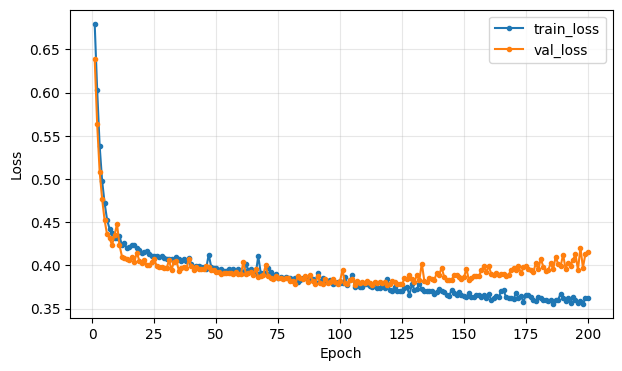

In [64]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [66]:
_, pred = evaluate(X_val_ts, y_val_ts, model5, loss_fn, device)

In [67]:
pred_class = np.where(pred.cpu().numpy() > 0.5, 1, 0)
pred_class[:5]

array([[1],
       [0],
       [1],
       [0],
       [0]])

In [68]:
confusion_matrix(y_val_ts.cpu().numpy(), pred_class)

array([[93, 15],
       [16, 55]])

In [69]:
print(classification_report(y_val_ts.cpu().numpy(), pred_class))

              precision    recall  f1-score   support

         0.0       0.85      0.86      0.86       108
         1.0       0.79      0.77      0.78        71

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

